# Домашнее задание 6:
## Тема: деревья решений и ансамбли (bagging / random forest / boosting / stacking) и честный ML-эксперимент.



In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import joblib
import json 
from pathlib import Path

from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    brier_score_loss,
    confusion_matrix
)

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,HistGradientBoostingClassifier, StackingClassifier
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42

DATA_PATH = 'data/'
FIG_PATH = 'figures/'
ARTIFACTS_DIR = Path("artifacts")
ART_PATH = "artifacts/"

In [2]:
def get_model_grade(model,X_val,y_val):
    y_val_pred = model.predict(X_val)
    y_val_proba = model.predict_proba(X_val)[:, 1]

    print("Accuracy :", accuracy_score(y_val, y_val_pred))
    print("Precision:", precision_score(y_val, y_val_pred, zero_division=0))
    print("Recall   :", recall_score(y_val, y_val_pred, zero_division=0))
    print("F1-score :", f1_score(y_val, y_val_pred, zero_division=0)) 
    print("ROC-AUC  :", roc_auc_score(y_val, y_val_proba))

def compute_metrics(y_true, y_pred, y_proba=None) -> dict:
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "recall" : float(recall_score(y_true,y_pred)),
        "precision" : float(precision_score(y_true,y_pred)),
        "f1": float(f1_score(y_true, y_pred)),
        "roc_auc" : float(roc_auc_score(y_true, y_proba))
    }

def evaluate_on_test(model, X_test, y_test, label: str) -> dict:
    pred = model.predict(X_test)
    proba = None
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_test)[:, 1]
    metrics = compute_metrics(y_test, pred, proba)
    metrics["model"] = label
    return metrics

def save_json(obj: dict, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)

def plot_confusion(y_true, y_pred, title: str):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    plt.imshow(cm)
    plt.title(title)
    plt.xlabel("pred")
    plt.ylabel("true")
    plt.xticks([0, 1])
    plt.yticks([0, 1])
    for (i, j), v in np.ndenumerate(cm):
        plt.text(j, i, str(v), ha="center", va="center")
    plt.savefig(ART_PATH+FIG_PATH+"confusion_matrix", dpi=300)
    plt.show()

def plot_roc(model, X_test, y_test, title: str):
    if not hasattr(model, "predict_proba"):
        print("ROC: модель не поддерживает predict_proba")
        return
    RocCurveDisplay.from_estimator(model, X_test, y_test)
    plt.title(title)
    plt.savefig(ART_PATH+FIG_PATH+"ROC_curve", dpi=300)
    plt.show()

def plot_pr(model, X_test, y_test, title: str):
    if not hasattr(model, "predict_proba"):
        print("ROC: модель не поддерживает predict_proba")
        return
    PrecisionRecallDisplay.from_estimator(model, X_test, y_test)
    plt.title(title)
    plt.savefig(ART_PATH+FIG_PATH+"PR_curve", dpi=300)
    plt.show()


# Загрузка данных и первичный анализ

In [3]:
df = pd.read_csv(DATA_PATH+'S06-hw-dataset-04.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 62 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      25000 non-null  int64  
 1   f01     25000 non-null  float64
 2   f02     25000 non-null  float64
 3   f03     25000 non-null  float64
 4   f04     25000 non-null  float64
 5   f05     25000 non-null  float64
 6   f06     25000 non-null  float64
 7   f07     25000 non-null  float64
 8   f08     25000 non-null  float64
 9   f09     25000 non-null  float64
 10  f10     25000 non-null  float64
 11  f11     25000 non-null  float64
 12  f12     25000 non-null  float64
 13  f13     25000 non-null  float64
 14  f14     25000 non-null  float64
 15  f15     25000 non-null  float64
 16  f16     25000 non-null  float64
 17  f17     25000 non-null  float64
 18  f18     25000 non-null  float64
 19  f19     25000 non-null  float64
 20  f20     25000 non-null  float64
 21  f21     25000 non-null  float64
 22

In [4]:
df.head()

,id,f01,f02,f03,f04,f05,f06,f07,f08,f09,...,f52,f53,f54,f55,f56,f57,f58,f59,f60,target
0,1,-1.250210,1.423474,-0.225004,-4.023138,-0.832729,-0.550874,1.772090,2.761690,-0.698750,...,10.938269,0.501178,1.600001,0.314212,1.209735,1.355697,-5.338924,1.153944,-0.153934,0
1,2,0.074328,0.376429,0.212831,-0.502074,2.017405,0.625496,1.943785,1.242030,-0.524090,...,7.775262,-4.550195,6.272586,-0.932162,-0.228543,1.735220,-3.827828,0.292165,0.273720,0
2,3,0.638481,0.060968,0.746760,2.479653,-0.292858,-0.078139,-2.918423,-0.013186,1.009135,...,-4.448447,-9.593179,-3.093519,0.029321,0.605511,0.829103,-0.085985,2.891408,0.766221,0
3,4,1.712916,-1.350969,-0.256473,1.622074,-0.445141,0.911932,-3.440345,1.505192,-1.104348,...,-1.619072,-3.237479,-5.474038,-1.582475,0.198137,3.823409,0.880395,1.148610,0.136732,0
4,5,0.905676,-0.206545,-0.068806,4.086026,-1.010045,-0.772644,-4.207688,2.506104,1.589143,...,-2.396844,-10.540129,-5.532811,-1.231203,0.000119,4.298572,-1.558235,0.924673,0.111668,0


In [5]:
sum(df.isnull().sum())

0

    Пропусков в данных нет.

In [6]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
id,25000.0,12500.500000,7217.022701,1.000000,6250.750000,12500.500000,18750.250000,25000.000000
f01,25000.0,-0.000386,1.001623,-4.370993,-0.680165,0.001859,0.679702,4.208888
f02,25000.0,-0.004872,0.995606,-4.087073,-0.675100,-0.000247,0.659523,3.984564
f03,25000.0,0.003202,1.004367,-4.103875,-0.675426,0.013272,0.683437,3.793442
f04,25000.0,0.335329,3.207537,-13.249937,-1.750048,0.403483,2.486453,15.288250
...,...,...,...,...,...,...,...,...
f57,25000.0,0.893365,2.445185,-9.508509,-0.735473,0.888535,2.516790,11.880651
f58,25000.0,-0.909479,1.962618,-7.919287,-2.226959,-0.923354,0.395648,6.778980
f59,25000.0,0.000570,0.994320,-4.038312,-0.666367,0.004381,0.666474,3.834922
f60,25000.0,-0.000754,0.997167,-3.812255,-0.665861,0.002420,0.665918,4.012639


In [7]:
df.select_dtypes('float64').shape[1]


60

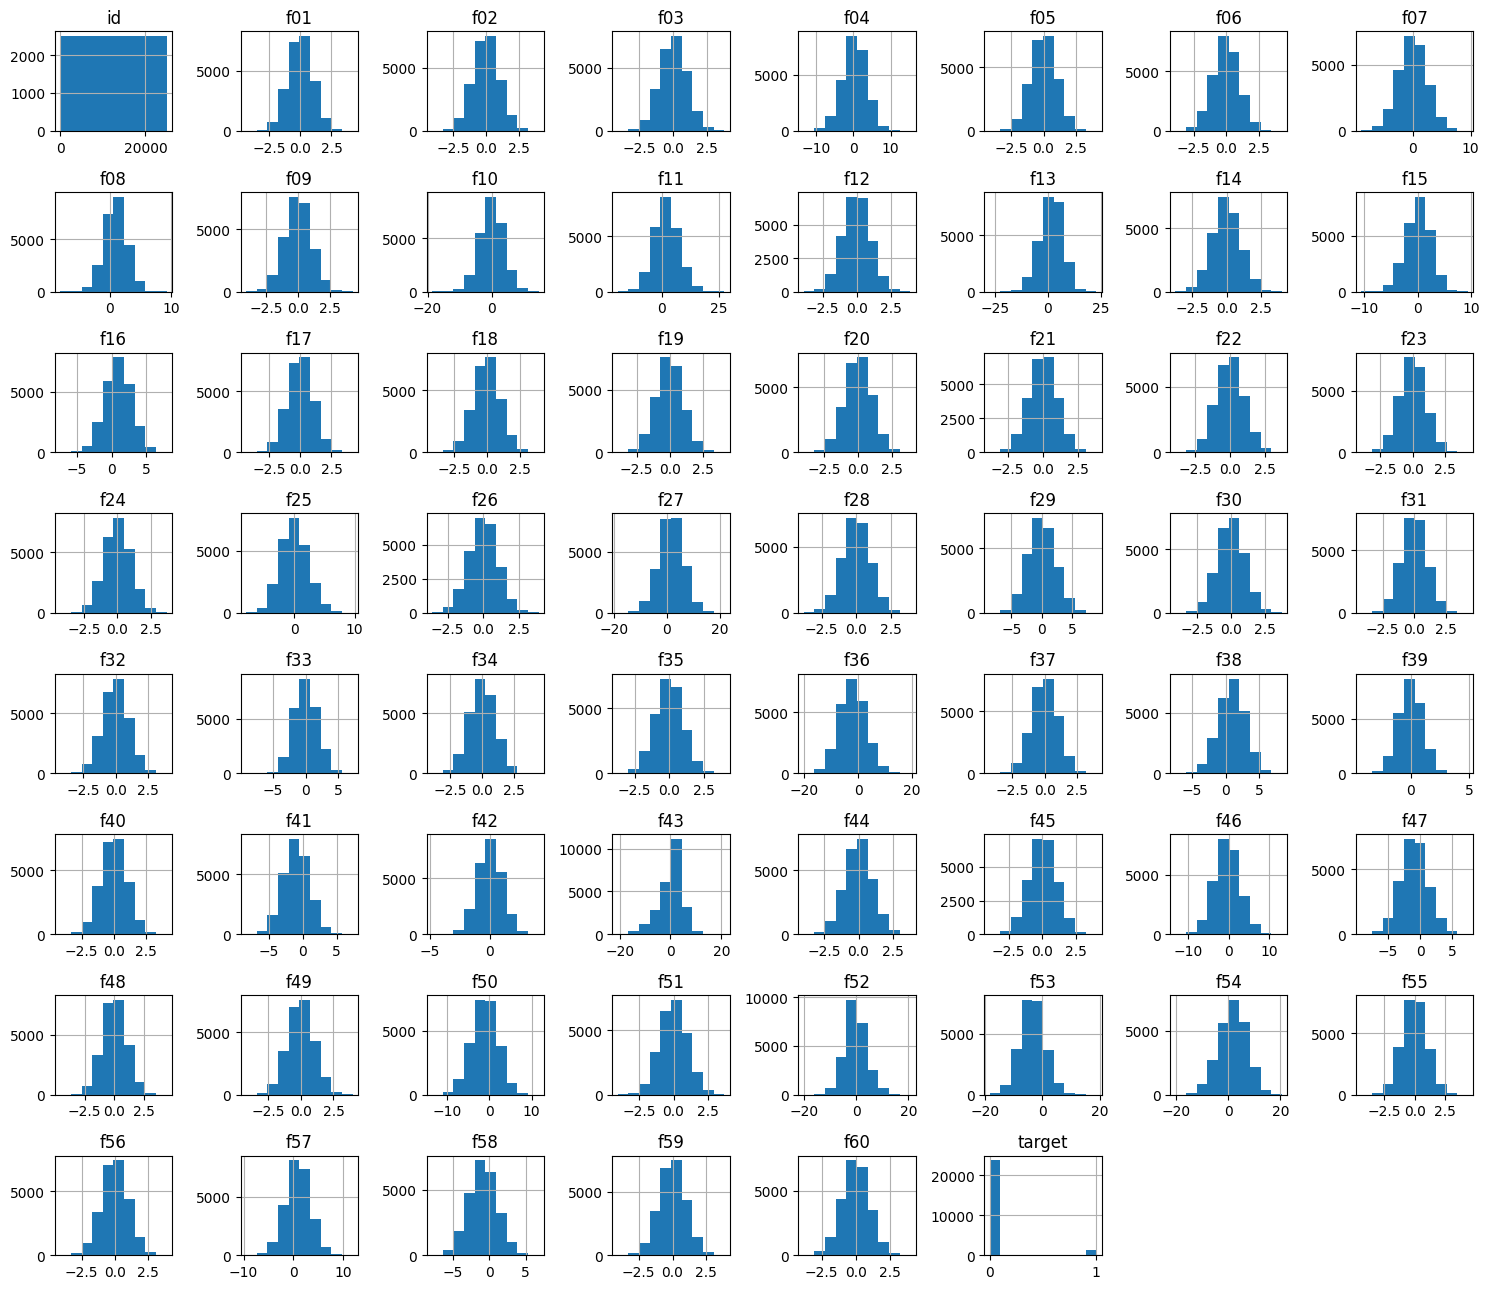

In [8]:
ax = df.hist(figsize=(15, 13))

plt.tight_layout()                       
plt.savefig(ART_PATH+FIG_PATH+"hist_all_columns.png", dpi=300)

    Распределение всех признаков близкое к нормальному.

In [9]:
df.select_dtypes('int64').shape[1]

2

    Мы видим, что в датасете встречаются только числовые значения, нет пропусков, 60 столбцов с плавабщей точкой, а два - с целым значением (это таргет и id). Колонок достаточно много, это затрудняет работу с данными. Данные неинтерпретируемы - не понятно, что значат названия колонок. 

In [10]:
df['target'].value_counts(normalize=True)

target
0    0.9508
1    0.0492
Name: proportion, dtype: float64

    Целевая переменная распределена неравномерно - 95 к 5. Это обязательно нужно будет учитывать при обучении и разбиении данных.

In [11]:
X = df.drop(columns=['id','target'])
y = df['target']
feature_names = X.columns

# Train/Test-сплит и воспроизводимость

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,         
    random_state=RANDOM_STATE,
)


In [13]:
print("Размеры выборок:")
print("  train:", X_train.shape)
print("  test: ", X_test.shape)

print("\nРаспределение классов (train):")
print(y_train.value_counts(normalize=True))


print("\nРаспределение классов (test):")
print(y_test.value_counts(normalize=True))

Размеры выборок:
  train: (20000, 60)
  test:  (5000, 60)

Распределение классов (train):
target
0    0.9508
1    0.0492
Name: proportion, dtype: float64

Распределение классов (test):
target
0    0.9508
1    0.0492
Name: proportion, dtype: float64


    Данные были поделены на тестовую, обучающую и валидационную выборки. Важно - учитываем дисбаланс классов, поэтому используем параметр stratify по целевой переменной. Тестовая выборка по размерам равна валидационной. Seed random state важен для слабоустойчивых моделей и позволяет зафиксировать результат, сделать его воспроизводимым. 

# Baseline’ы

In [14]:
dc_baseline = DummyClassifier(
    strategy="stratified",
    random_state=RANDOM_STATE
)
dc_baseline.fit(X_train,y_train)

get_model_grade(model=dc_baseline,X_val=X_test,y_val=y_test)

Accuracy : 0.905
Precision: 0.03643724696356275
Recall   : 0.036585365853658534
F1-score : 0.036511156186612576
ROC-AUC  : 0.4932611305498836


    Видим, модель показала высокий accuracy, но другие метрики (точность, полнота и их гармоническое среднее) очень низкие.

In [15]:
log_reg_pipeline = Pipeline(
    steps = [
    ("scaler", StandardScaler()),
    ("logreg", 
        LogisticRegression(
            max_iter=5000,
            l1_ratio=0,
            C=1.0,
            solver='liblinear',
            random_state=RANDOM_STATE,
        ),
    ),
])

log_reg_pipeline.fit(X_train, y_train)
get_model_grade(model=log_reg_pipeline,X_val=X_test,y_val=y_test)


Accuracy : 0.9632
Precision: 0.9078947368421053
Recall   : 0.2804878048780488
F1-score : 0.42857142857142855
ROC-AUC  : 0.8340712656179989


    Модель линейной регрессии более полно оценивает данные. Однако все равно recall и f1 достаточно низкие (даже < 0.5). В дальнейшем буду смотреть в первую очередь на f1, так как она наиболее полно показывает качество классификации при явном дисбалансе классов.

In [16]:
joblib.dump(dc_baseline,ART_PATH+"models/dc_baseline.joblib")

['artifacts/models/dc_baseline.joblib']

In [17]:
joblib.dump(log_reg_pipeline,ART_PATH+"models/log_reg.joblib")

['artifacts/models/log_reg.joblib']

    Сохраняем модели в артефакты. Важно - директория models не коммитится, так как много весит. Для версионирования больших данных можно использовать dvc, а не git.

# Модели недели 6

In [18]:
results = []
best_models = {}  
search_summaries = {}  
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)   

def run_search(label: str, estimator, param_grid: dict):
    search = GridSearchCV(
        estimator,
        param_grid,
        scoring="f1",
        cv=cv,
        n_jobs=-1,
        refit=True,
        return_train_score=True
    )
    search.fit(X_train, y_train)

    best = search.best_estimator_
    best_models[label] = best
    search_summaries[label] = {
        "best_params": search.best_params_,
        "best f1 score": float(search.best_score_),
    }
    results.append(evaluate_on_test(best, X_test, y_test, label))
    return search

In [19]:
results.append(evaluate_on_test(dc_baseline, X_test, y_test, "Dummy"))
results.append(evaluate_on_test(log_reg_pipeline, X_test, y_test, "LogReg"))

    Метрика для сравнения f1. Полный перебор через кросс-валидацию с stratify по таргету.

## Decision Tree

In [20]:
import os
os.environ['PYDEVD_DISABLE_FILE_VALIDATION'] = '1' # убрать warning

dt = DecisionTreeClassifier(random_state=RANDOM_STATE)

dt_grid = {
    "max_depth": [None, 3, 8,15],
    "min_samples_leaf": [3, 10,20],
    "max_features": [None, 'sqrt', 'log2'],
    "ccp_alpha": [0.0, 0.001, 0.01],
    "criterion": ["gini", "entropy"],
    "class_weight": ['balanced', {0:1,1:3}, {0:1,1:10}],
}

dt_search = run_search("DecisionTree", dt, dt_grid)
search_summaries["DecisionTree"]

{'best_params': {'ccp_alpha': 0.0,
  'class_weight': {0: 1, 1: 3},
  'criterion': 'gini',
  'max_depth': 8,
  'max_features': None,
  'min_samples_leaf': 10},
 'best f1 score': 0.5743237651395751}

    Результат - лучше всего работает дерево с неограниченной сложностью, 10 примеров в листе минимум и минимальный штраф за сложность ccp_alpha (регуляризация), но не отсутствие штрафа совсем. Вес классов тоже важен - 1 к 3 лучший результат. Мое мнение - дереву либо не хватает сложности, либо данных. (Их можно будет синтезировать для лучшей модели). Количество признаков лучше не ограничивать - поэтому можно сделать вывод, что данные не шумные.

## Random Forest

In [21]:
rf = RandomForestClassifier(
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

rf_grid = {
    "n_estimators": [600],
    "max_depth": [None, 15],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 5],
    "class_weight": ['balanced', {0:1,1:5}],
    "ccp_alpha": [0.0, 0.001]
}


rf_search = run_search("RandomForest", rf, rf_grid)
search_summaries["RandomForest"]


{'best_params': {'ccp_alpha': 0.001,
  'class_weight': 'balanced',
  'max_depth': 15,
  'min_samples_leaf': 5,
  'min_samples_split': 2,
  'n_estimators': 600},
 'best f1 score': 0.7105359628012818}

    Результат случайного леса намного лучше, чем у одного дерева. А значит под данный датасет лучше подходят более сложные модели, умеющие работать с дисбалансом

## Hist Gradient Boosting

In [22]:
hgb = HistGradientBoostingClassifier(
    random_state=RANDOM_STATE,
    early_stopping=True
)

hgb_grid = {
    "learning_rate": [0.01, 0.1],
    "max_iter": [100, 200],                    
    "max_depth": [3, 5, None],
    "l2_regularization": [0.0, 0.5],
    "min_samples_leaf": [20, 50],
    "max_features": [0.8, 1.0],
    "class_weight": ['balanced', {0:1,1:3}, {0:1,1:10}],
}




hgb_search = run_search("HistGradientBoosting", hgb, hgb_grid)
search_summaries["HistGradientBoosting"]

{'best_params': {'class_weight': {0: 1, 1: 3},
  'l2_regularization': 0.0,
  'learning_rate': 0.1,
  'max_depth': None,
  'max_features': 0.8,
  'max_iter': 100,
  'min_samples_leaf': 20},
 'best f1 score': 0.7427293922868391}

    Результат еще лучше - модель достаточно хорошо справилась.

## Stacking with cv

In [23]:
results

[{'accuracy': 0.905,
  'recall': 0.036585365853658534,
  'precision': 0.03643724696356275,
  'f1': 0.036511156186612576,
  'roc_auc': 0.4932611305498836,
  'model': 'Dummy'},
 {'accuracy': 0.9632,
  'recall': 0.2804878048780488,
  'precision': 0.9078947368421053,
  'f1': 0.42857142857142855,
  'roc_auc': 0.8340712656179989,
  'model': 'LogReg'},
 {'accuracy': 0.9618,
  'recall': 0.5365853658536586,
  'precision': 0.631578947368421,
  'f1': 0.5802197802197803,
  'roc_auc': 0.8270797206289269,
  'model': 'DecisionTree'},
 {'accuracy': 0.9758,
  'recall': 0.7276422764227642,
  'precision': 0.7682403433476395,
  'f1': 0.7473903966597077,
  'roc_auc': 0.8933982850556313,
  'model': 'RandomForest'},
 {'accuracy': 0.981,
  'recall': 0.6666666666666666,
  'precision': 0.9265536723163842,
  'f1': 0.7754137115839244,
  'roc_auc': 0.9033676390613297,
  'model': 'HistGradientBoosting'}]

In [24]:
best_models

{'DecisionTree': DecisionTreeClassifier(class_weight={0: 1, 1: 3}, max_depth=8,
                        min_samples_leaf=10, random_state=42),
 'RandomForest': RandomForestClassifier(ccp_alpha=0.001, class_weight='balanced', max_depth=15,
                        min_samples_leaf=5, n_estimators=600, n_jobs=-1,
                        random_state=42),
 'HistGradientBoosting': HistGradientBoostingClassifier(class_weight={0: 1, 1: 3}, early_stopping=True,
                                max_features=0.8, random_state=42)}

In [25]:
search_summaries 

{'DecisionTree': {'best_params': {'ccp_alpha': 0.0,
   'class_weight': {0: 1, 1: 3},
   'criterion': 'gini',
   'max_depth': 8,
   'max_features': None,
   'min_samples_leaf': 10},
  'best f1 score': 0.5743237651395751},
 'RandomForest': {'best_params': {'ccp_alpha': 0.001,
   'class_weight': 'balanced',
   'max_depth': 15,
   'min_samples_leaf': 5,
   'min_samples_split': 2,
   'n_estimators': 600},
  'best f1 score': 0.7105359628012818},
 'HistGradientBoosting': {'best_params': {'class_weight': {0: 1, 1: 3},
   'l2_regularization': 0.0,
   'learning_rate': 0.1,
   'max_depth': None,
   'max_features': 0.8,
   'max_iter': 100,
   'min_samples_leaf': 20},
  'best f1 score': 0.7427293922868391}}

In [26]:
estimators = [
    ("dt", best_models["DecisionTree"]),
    ("rf", best_models["RandomForest"]),
    ("hgb", best_models["HistGradientBoosting"]),
]

stack = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=4000, random_state=RANDOM_STATE),
    cv=5,
    n_jobs=-1,
    passthrough=False
)

stack.fit(X_train, y_train)
best_models["Stacking"] = stack
results.append(evaluate_on_test(stack, X_test, y_test, "Stacking"))

{"note": "stacking fitted"}

{'note': 'stacking fitted'}

# Анализ результатов

In [27]:
df = pd.DataFrame(results)

# сортировка: roc_auc (если есть) иначе accuracy
df_sorted = df.copy()
df_sorted["f1"] = df_sorted["f1"].fillna(-1.0)
df_sorted = df_sorted.sort_values(["f1"], ascending=False).drop(columns=["f1"])

df_sorted

,accuracy,recall,precision,roc_auc,model
5,0.9806,0.686992,0.894180,0.897755,Stacking
4,0.9810,0.666667,0.926554,0.903368,HistGradientBoosting
3,0.9758,0.727642,0.768240,0.893398,RandomForest
2,0.9618,0.536585,0.631579,0.827080,DecisionTree
1,0.9632,0.280488,0.907895,0.834071,LogReg
0,0.9050,0.036585,0.036437,0.493261,Dummy


In [28]:
metrics_path = ARTIFACTS_DIR / "metrics_test.json"
search_path = ARTIFACTS_DIR / "search_summaries.json"

save_json({"results": df_sorted.to_dict(orient="records")}, metrics_path)
save_json(search_summaries, search_path)

print("Saved:", metrics_path)
print("Saved:", search_path)

Saved: artifacts/metrics_test.json
Saved: artifacts/search_summaries.json


In [29]:
best_row = df_sorted.iloc[0]
best_label = best_row["model"]
best_model = best_models[best_label]

best_label, best_row.to_dict()

('Stacking',
 {'accuracy': 0.9806,
  'recall': 0.6869918699186992,
  'precision': 0.8941798941798942,
  'roc_auc': 0.8977549072924469,
  'model': 'Stacking'})

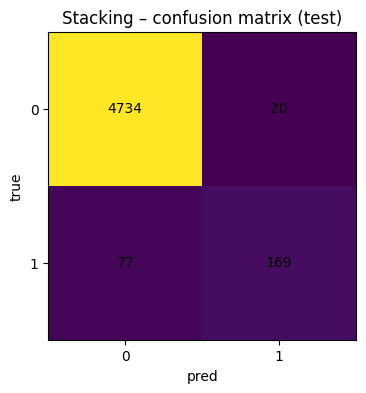

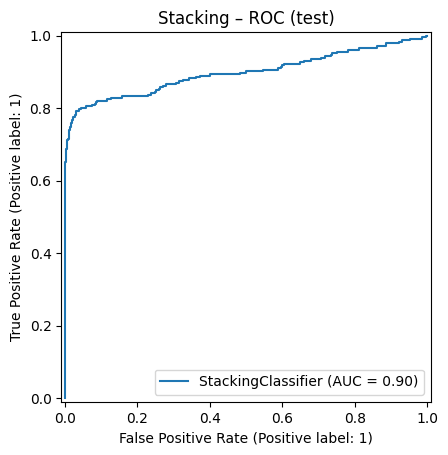

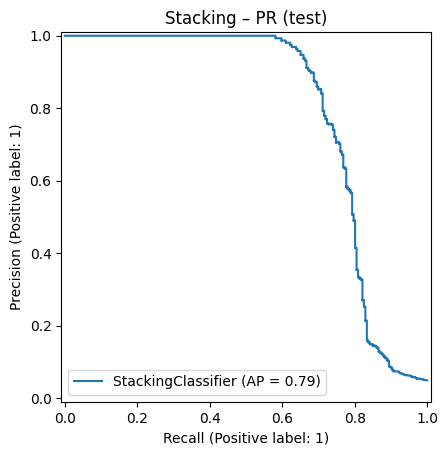

In [30]:
y_pred = best_model.predict(X_test)
plot_confusion(y_test, y_pred, title=f"{best_label} – confusion matrix (test)")
plot_roc(best_model, X_test, y_test, title=f"{best_label} – ROC (test)")
plot_pr(best_model, X_test, y_test, title=f"{best_label} – PR (test)")

In [31]:
get_model_grade(best_model,X_test,y_test)

Accuracy : 0.9806
Precision: 0.8941798941798942
Recall   : 0.6869918699186992
F1-score : 0.7770114942528735
ROC-AUC  : 0.8977549072924469


    Результат - модель верно распознает отрицательные классы, но хуже распознает положительын из-за их маленького количества

# Интерпретация модели

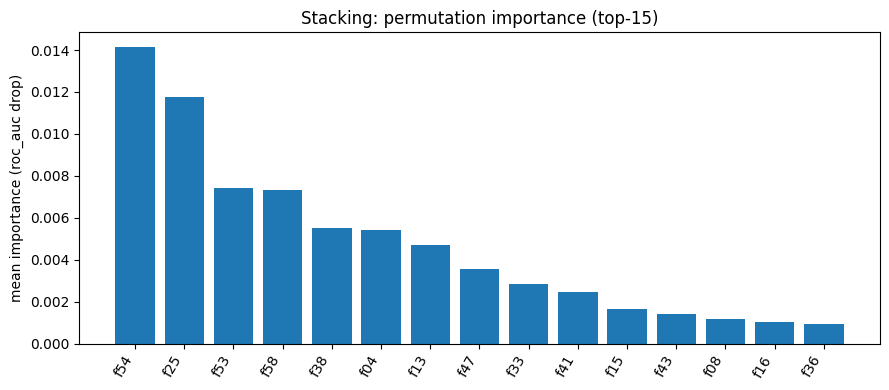

In [32]:
scoring = "roc_auc" if hasattr(best_model, "predict_proba") else "accuracy"

perm = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=8,
    random_state=RANDOM_STATE,
    scoring=scoring
)

imp = perm.importances_mean
idx = np.argsort(imp)[::-1][:15]

plt.figure(figsize=(9, 4))
plt.bar(range(len(idx)), imp[idx])
plt.xticks(range(len(idx)), [feature_names[i] for i in idx], rotation=60, ha="right")
plt.ylabel(f"mean importance ({scoring} drop)")
plt.title(f"{best_label}: permutation importance (top-15)")
plt.tight_layout()
plt.savefig(ART_PATH+FIG_PATH+"permutation_importance", dpi=300)
plt.show()

    Признаки имеют непонятные названия, поэтому тяжело проинтерпретировать результат.

In [33]:
model_path = ARTIFACTS_DIR / "best_model.joblib"
joblib.dump(best_model, model_path)

meta = {
    "best_model_label": best_label,
    "test_metrics": best_row.to_dict(),
    "search_summary": search_summaries.get(best_label, None),
    "random_state": RANDOM_STATE,
}
save_json(meta, ARTIFACTS_DIR / "best_model_meta.json")

print("Saved:", model_path)
print("Saved:", ARTIFACTS_DIR / "best_model_meta.json")

Saved: artifacts/best_model.joblib
Saved: artifacts/best_model_meta.json


    Вывод - на данных с сильным дисбалансом классов нет смысла смотреть на accuracy, он может быть высоким даже при плохой классификации. Можно выбрать, например, F меру. Я сравнила 6 алгоритмов машинного обучения - базовый классификатор (самый встречаемый класс), линейную регрессию, случайный лес, деревья, бустинг и стекинг. Лучше всех себя показал стекинг - объединение результатов разнородовых моделей. Обучение и сравнение моделей происходило в кросс-валидации. Результат - 

# Устойчивость модели

In [34]:
scores = []
STATE = [0,77,99]
for s in STATE:
    estimators = [
        ("dt", best_models["DecisionTree"]),
        ("rf", best_models["RandomForest"]),
        ("hgb", best_models["HistGradientBoosting"]),
    ]
    stack = StackingClassifier(
        estimators=estimators,
        final_estimator=LogisticRegression(max_iter=4000, random_state=s),
        cv=5,
        n_jobs=-1,
        passthrough=False
    )

    stack.fit(X_train, y_train)
    y_pred = stack.predict(X_test)
    score = f1_score(y_test, y_pred)
    scores.append(score)
    print(f'state={s}, F1={score:.4f}')

print(f"Mean: {np.mean(scores):.4f}, Std: {np.std(scores):.4f}")
print(f"Coeff. of variation: {np.std(scores)/np.mean(scores)*100:.1f}%")

state=0, F1=0.7770
state=77, F1=0.7770
state=99, F1=0.7770
Mean: 0.7770, Std: 0.0000
Coeff. of variation: 0.0%


    Значение всех метрик одно и то же => модель стекинга устойчива.

In [35]:
scores = []
STATE = [0,77,99]
for s in STATE:
    hgb = HistGradientBoostingClassifier(
        random_state=s,
        early_stopping=True,
        class_weight = {0: 1, 1: 3},
        l2_regularization = 0.0,
        learning_rate = 0.1,
        max_depth = None,
        max_features = 0.8,
        max_iter = 100,
        min_samples_leaf = 20
    )
    hgb.fit(X_train, y_train)
    y_pred = hgb.predict(X_test)
    score = f1_score(y_test, y_pred)
    scores.append(score)
    print(f'state={s}, F1={score:.4f}')

print(f"Mean: {np.mean(scores):.4f}, Std: {np.std(scores):.4f}")
print(f"Coeff. of variation: {np.std(scores)/np.mean(scores)*100:.1f}%")
    

state=0, F1=0.7757
state=77, F1=0.7822
state=99, F1=0.7703
Mean: 0.7761, Std: 0.0049
Coeff. of variation: 0.6%


    Модель градиентного бустинга также является устойчивой.

# Дополнительно - калибровка вероятностей.

In [36]:
calib_model = CalibratedClassifierCV(
    best_model, 
    method='sigmoid',  # Platt scaling для деревьев
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
)
calib_model.fit(X_train, y_train)


# Сравнение Brier score (меньше = лучше калибровка)
y_proba_raw = best_model.predict_proba(X_test)[:, 1]
y_proba_calib = calib_model.predict_proba(X_test)[:, 1]

brier_raw = brier_score_loss(y_test, y_proba_raw)
brier_calib = brier_score_loss(y_test, y_proba_calib)

print(f"Brier raw:    {brier_raw:.4f}")
print(f"Brier calib:  {brier_calib:.4f}")
print(f"Улучшение:    {((brier_raw - brier_calib)/brier_raw*100):+.1f}%")



Brier raw:    0.0170
Brier calib:  0.0169
Улучшение:    +0.6%


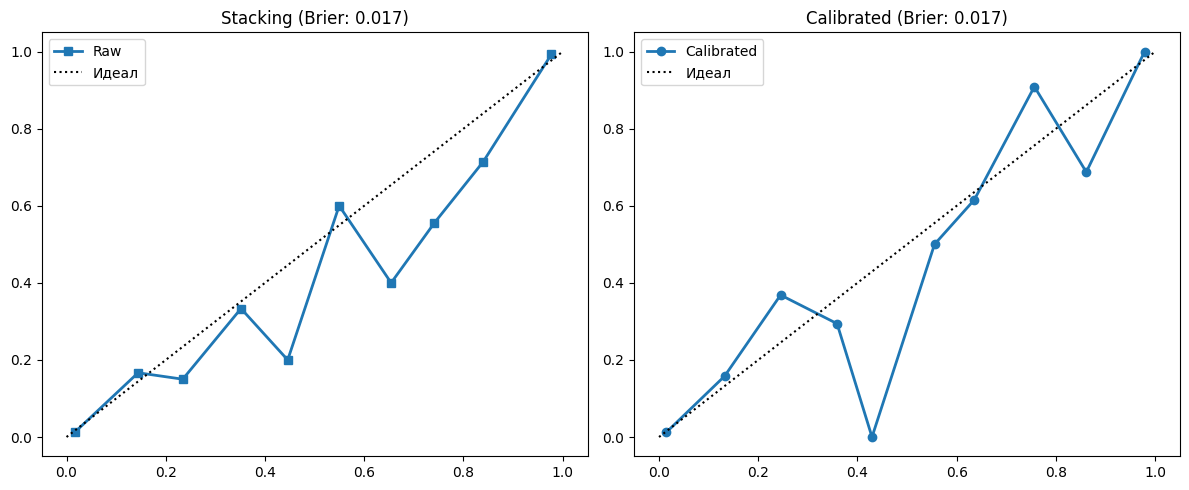

In [37]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
frac_raw, mean_raw = calibration_curve(y_test, y_proba_raw, n_bins=10)
ax1.plot(mean_raw, frac_raw, "s-", label="Raw", linewidth=2)
ax1.plot([0, 1], [0, 1], "k:", label="Идеал")
ax1.set_title(f"{best_label} (Brier: {brier_raw:.3f})")
ax1.legend()

frac_calib, mean_calib = calibration_curve(y_test, y_proba_calib, n_bins=10)
ax2.plot(mean_calib, frac_calib, "o-", label="Calibrated", linewidth=2)
ax2.plot([0, 1], [0, 1], "k:", label="Идеал")
ax2.set_title(f"Calibrated (Brier: {brier_calib:.3f})")
ax2.legend()

plt.tight_layout()
plt.savefig(f"artifacts/figures/{best_label}_calibration.png", dpi=300, bbox_inches='tight')
plt.show()

    Калибровка модели не привела к результату.